In [25]:
# Cell 1: imports

from functools import partial
import importlib

import matplotlib.pyplot as plt
import torch

import vt_all_solvers_wrapper as vt
import dataset
import utils

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)

from base_range_library import range_library
from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from utils import TrainConfig, fit, make_optimizer, mse_loss, plot_history
from models.mlp import ProfileMLP, webster_mlp_batch_to_xy
from models.fno import TransferFunctionFNO, webster_fno_batch_to_xy


In [26]:
# Cell 2: общие параметры

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
sections = 100
n_profile_points = 128
n_frequencies = 256

# Для быстрых smoke-тестов можно уменьшить, но 100 шагов обычно мало для FNO.
steps_per_epoch = 200
val_steps = 10
epochs = 20

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
)

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=1,
)

val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=100_000,
    max_samples=batch_size * val_steps,
)


In [27]:
# Cell 3: dataloaders

train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

val_loader = make_streaming_dataloader(
    val_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

In [28]:
# Cell 4: MLP/FNO batch adapters

mlp_batch_to_xy = partial(
    webster_mlp_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
)

fno_batch_to_xy = partial(
    webster_fno_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
)


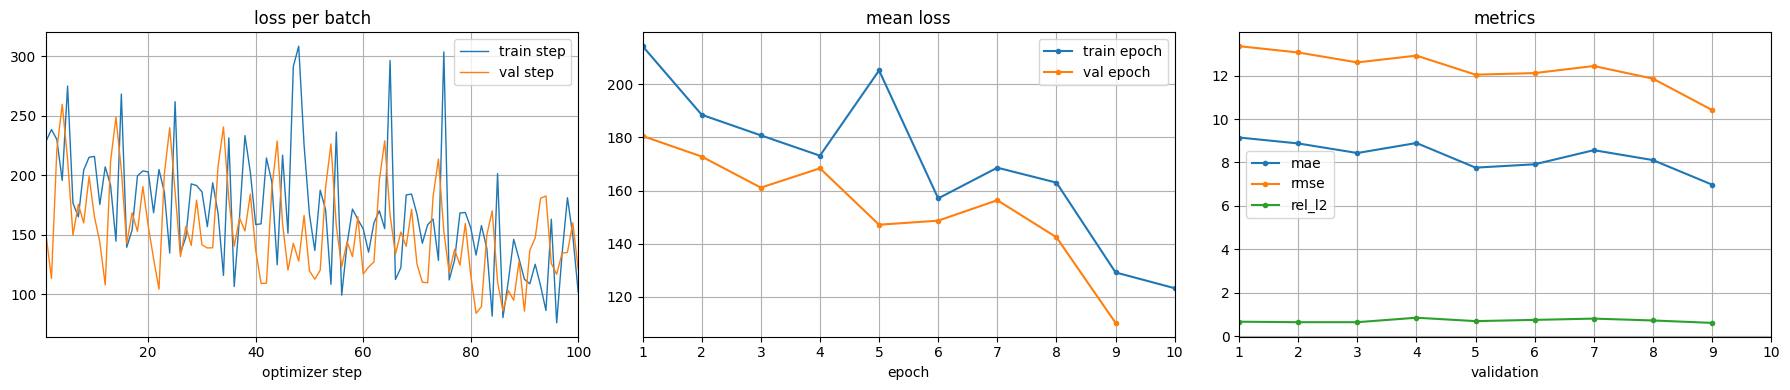

epoch 010/10 | train=123.177 | val=144.043 | lr=0.001


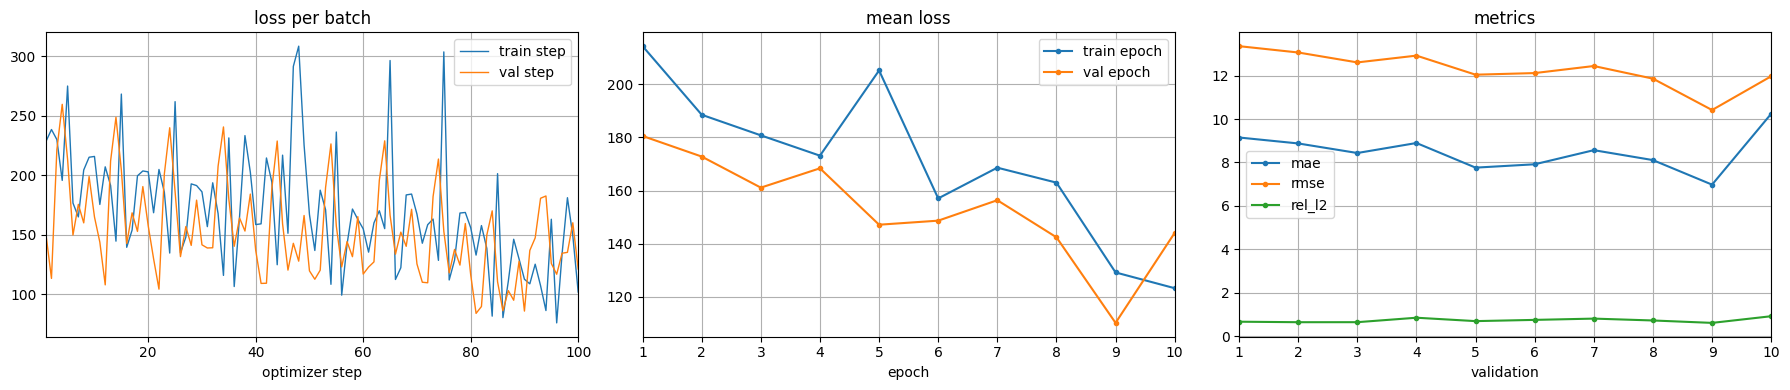

In [29]:
# Cell 5: train MLP

mlp = ProfileMLP(
    n_profile_points=n_profile_points,
    in_channels=2,  # log(area), x
    n_frequencies=n_frequencies,
    hidden_dim=512,
    depth=4,
    dropout=0.05,
    out_channels=1,
).to(device)

mlp_optimizer = make_optimizer(
    mlp,
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_history = fit(
    mlp,
    mlp_optimizer,
    train_loader,
    val_loader,
    criterion=mse_loss,
    batch_to_xy=mlp_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name="mlp_db",
        save_every_steps=None,
    ),
)

plot_history(mlp_history)


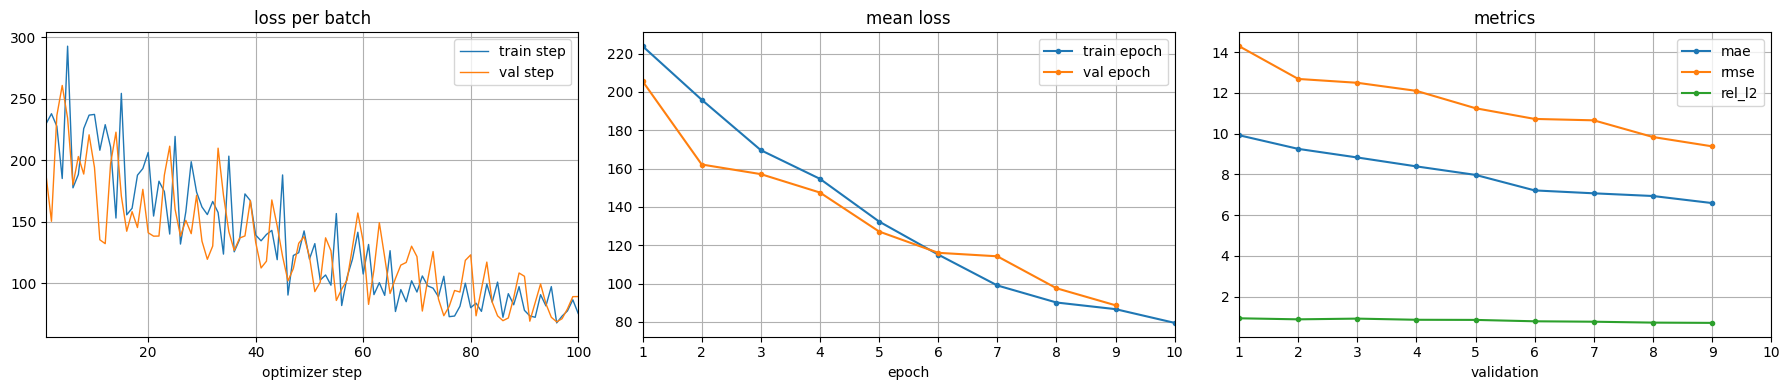

epoch 010/10 | train=79.4998 | val=80.4786 | lr=0.001


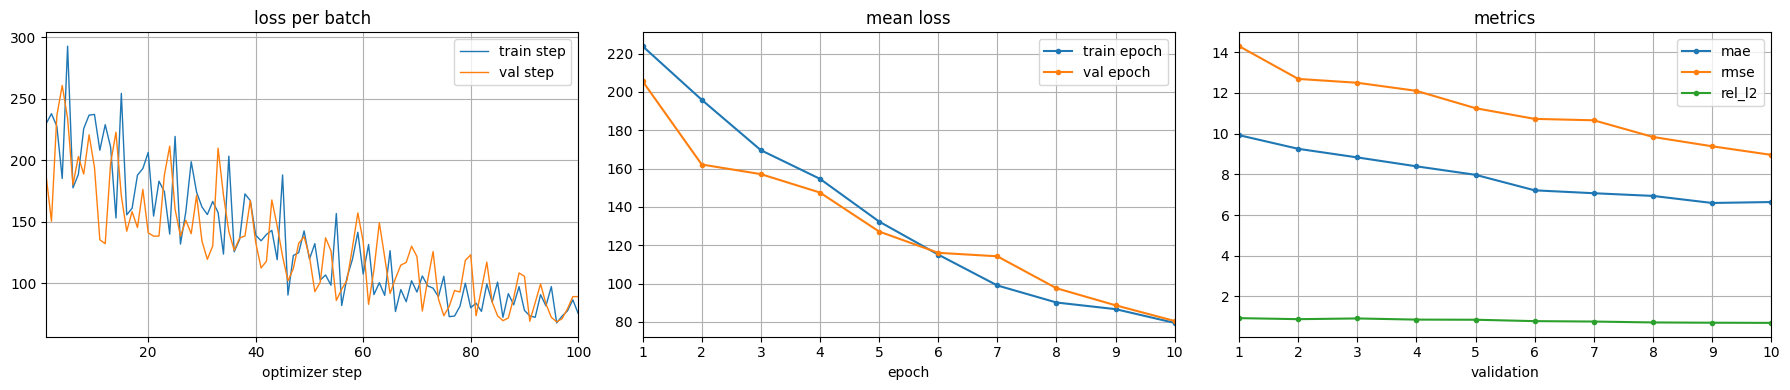

In [30]:
# Cell 6: train FNO

fno = TransferFunctionFNO(
    n_modes=32,
    hidden_channels=96,
    latent_dim=256,
    pooling_bins=16,
    frequency_bands=16,
    out_channels=1,  # dB: output shape [B, Nf]
).to(device)

fno_optimizer = make_optimizer(
    fno,
    lr=5e-4,
    weight_decay=1e-4,
)

fno_history = fit(
    fno,
    fno_optimizer,
    train_loader,
    val_loader,
    criterion=mse_loss,
    batch_to_xy=fno_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name="fno_db",
        save_every_steps=None,
    ),
)

plot_history(fno_history)


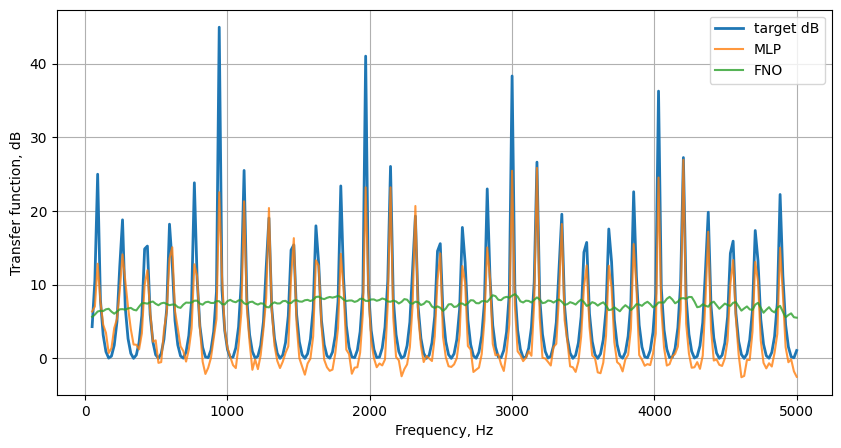

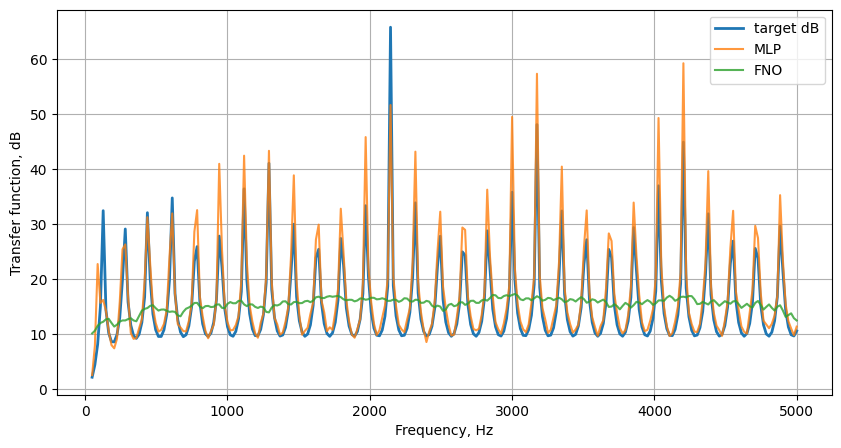

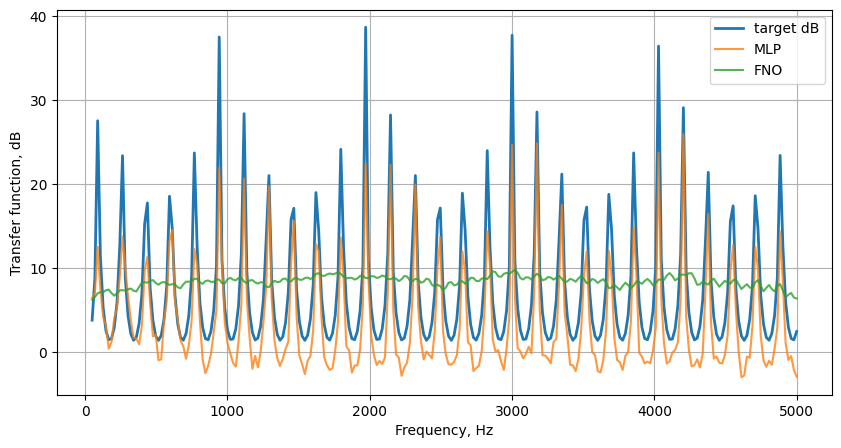

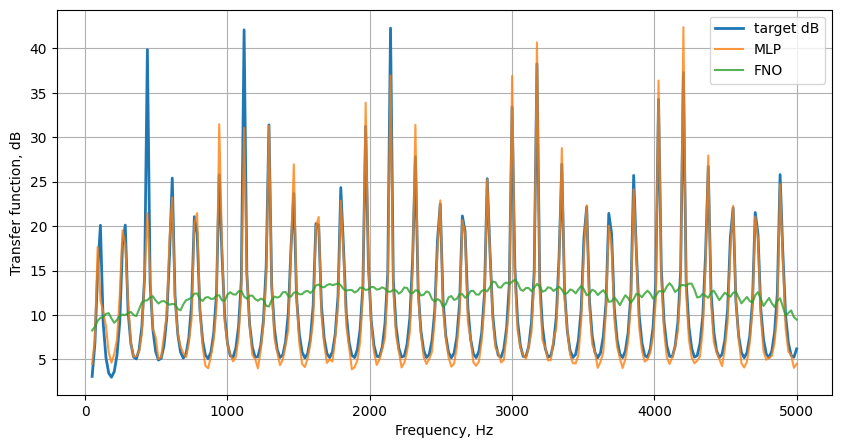

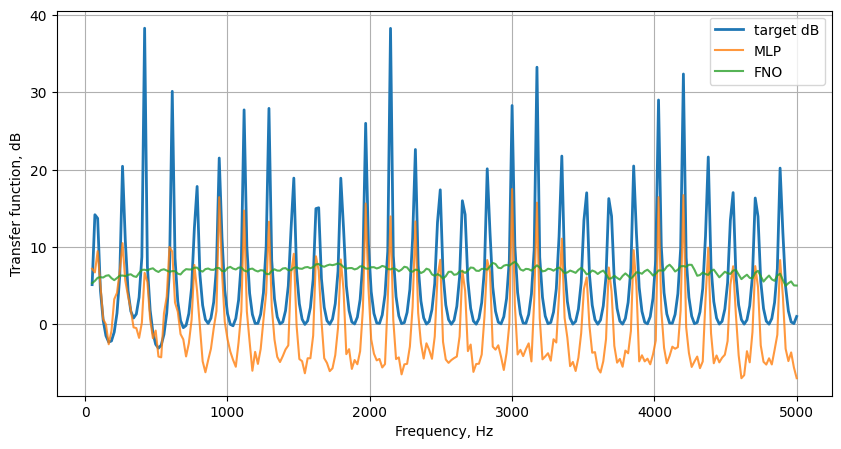

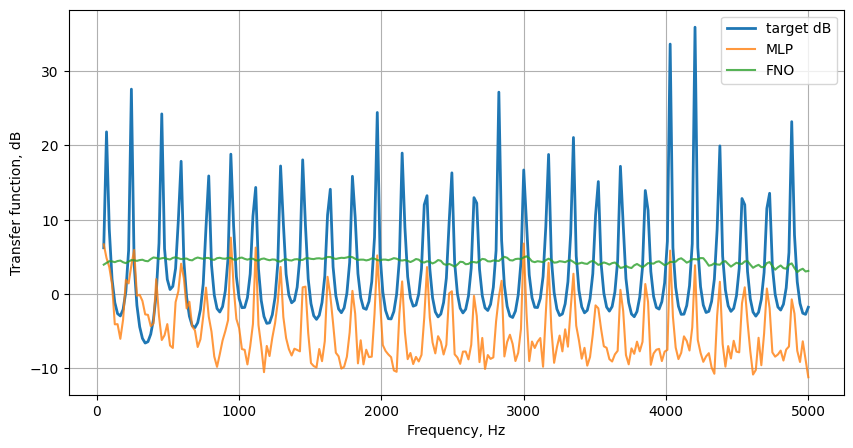

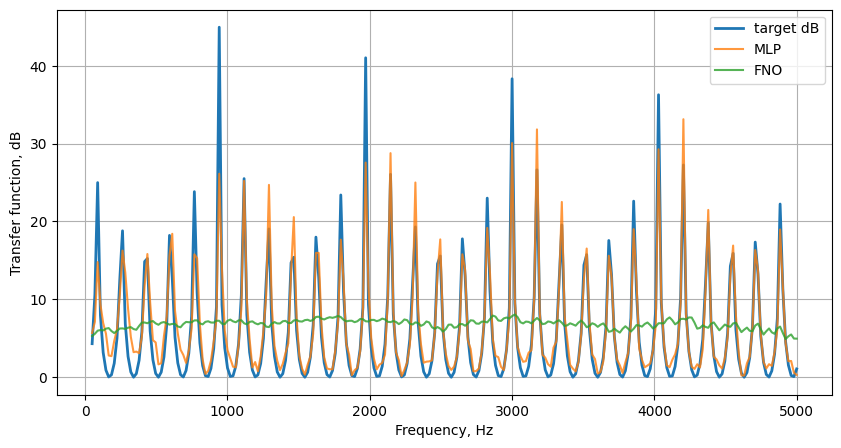

KeyboardInterrupt: 

In [31]:
# Cell 7: сравнение на одном validation batch

val_iter = iter(val_loader)
batch = next(val_iter)
sample_idx = 0

mlp.eval()
fno.eval()

with torch.no_grad():
    x_mlp, y = mlp_batch_to_xy(batch, torch.device(device))
    pred_mlp = mlp(x_mlp)

    x_fno, _ = fno_batch_to_xy(batch, torch.device(device))
    pred_fno = fno(*x_fno)

freq = batch["frequencies_hz"][sample_idx].cpu()
target = y[sample_idx].cpu()
mlp_pred = pred_mlp[sample_idx].cpu()
fno_pred = pred_fno[sample_idx].cpu()

plt.figure(figsize=(10, 5))
plt.plot(freq, target, label="target dB", linewidth=2)
plt.plot(freq, mlp_pred, label="MLP", alpha=0.8)
plt.plot(freq, fno_pred, label="FNO", alpha=0.8)
plt.xlabel("Frequency, Hz")
plt.ylabel("Transfer function, dB")
plt.grid(True)
plt.legend()
plt.show()


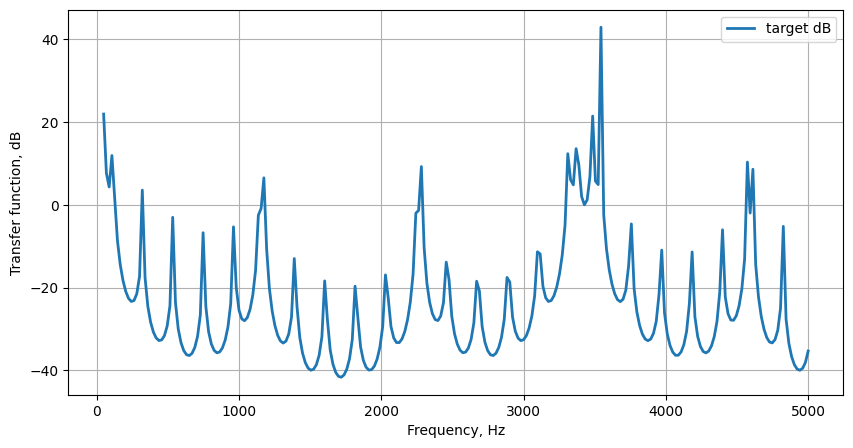

In [ ]:
# Cell 8: sanity-check target only

batch = next(iter(val_loader))
sample_idx = 2

with torch.no_grad():
    _, y = mlp_batch_to_xy(batch, torch.device(device))

freq = batch["frequencies_hz"][sample_idx].cpu()
target = y[sample_idx].cpu()

plt.figure(figsize=(10, 5))
plt.plot(freq, target, label="target dB", linewidth=2)
plt.xlabel("Frequency, Hz")
plt.ylabel("Transfer function, dB")
plt.grid(True)
plt.legend()
plt.show()
